In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data.csv',encoding='latin1')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Task 1

<Axes: xlabel='Sales', ylabel='Count'>

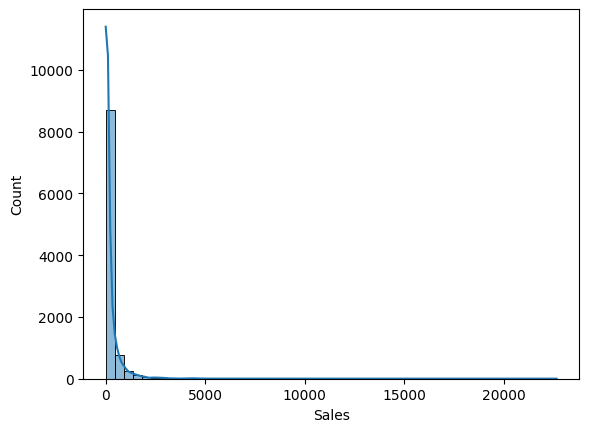

In [6]:
sns.histplot(df['Sales'],kde=True,bins=50)

In [7]:
df['Sales'].agg(['mean','median'])

,Sales
mean,229.858001
median,54.490000


In [ ]:
# The sales column is right skewed. Mean wouldn't be good measure to summarize the sales because outliers are stretching the mean

# Task 2

<Axes: xlabel='Category', ylabel='Profit'>

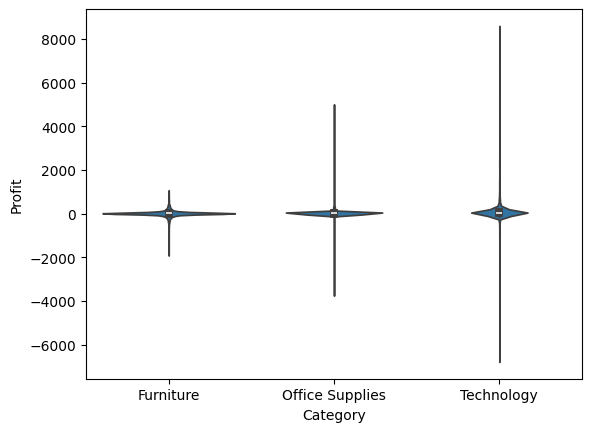

In [8]:
sns.violinplot(x='Category',y='Profit',data=df)

<Axes: xlabel='Category', ylabel='Profit'>

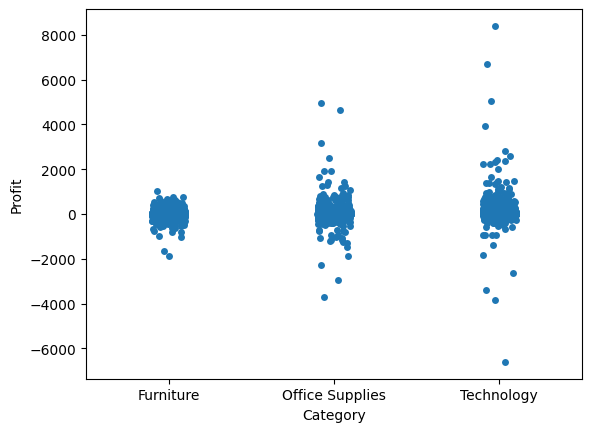

In [9]:
sns.stripplot(x='Category',y='Profit',data=df)

In [ ]:
# strip plot show better distribution (in this case) as it clearly shows outliers (higher) profit for categories and easy to interpret the distribution for bimodal violin may work

# Task 3

<Axes: xlabel='Discount', ylabel='Profit'>

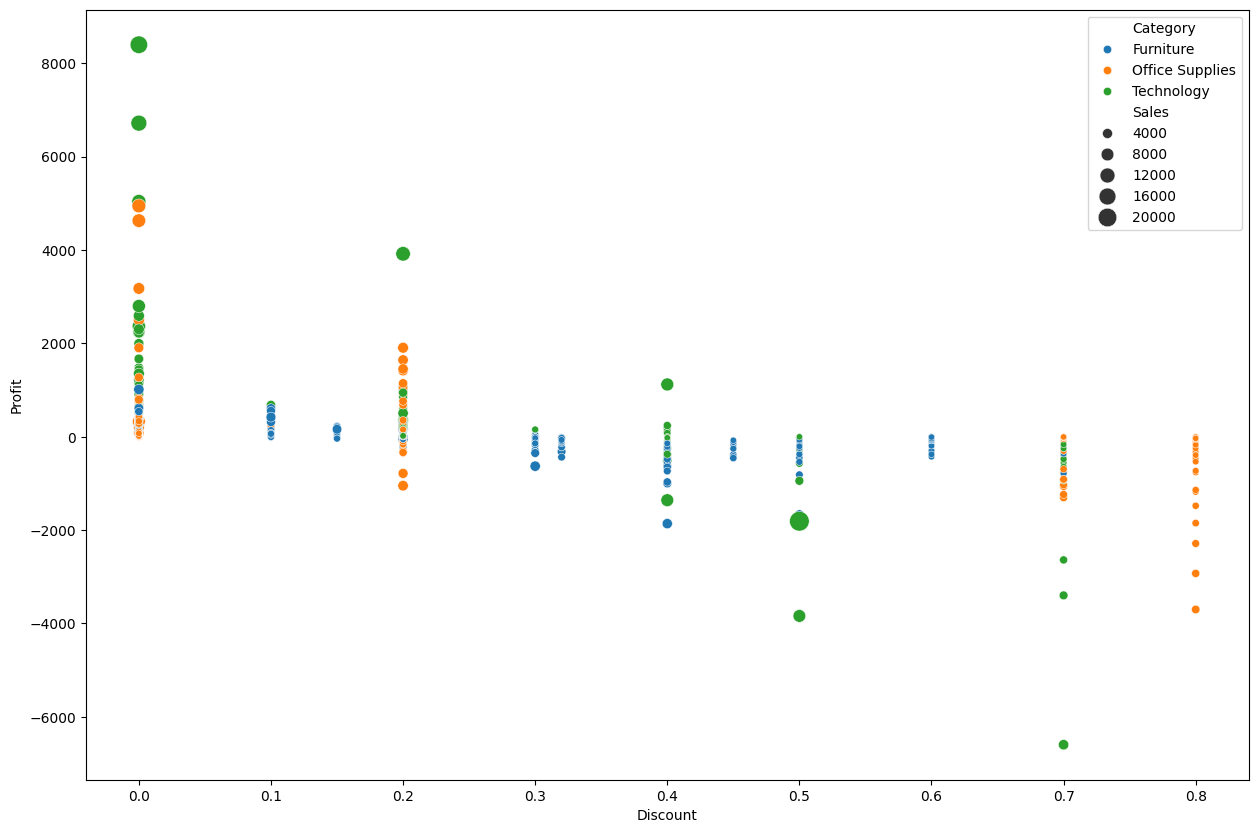

In [16]:
plt.figure(figsize=(15,10))
sns.scatterplot(x='Discount',y='Profit',hue='Category',size='Sales',data=df,sizes=(20,200))


In [ ]:
# technology products has higher sales

# Task 4

In [17]:
df.corr(numeric_only=True,method= 'pearson')

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
Row ID,1.000000,0.009671,-0.001359,-0.004016,0.013480,0.012497
Postal Code,0.009671,1.000000,-0.023854,0.012761,0.058443,-0.029961
Sales,-0.001359,-0.023854,1.000000,0.200795,-0.028190,0.479064
Quantity,-0.004016,0.012761,0.200795,1.000000,0.008623,0.066253
Discount,0.013480,0.058443,-0.028190,0.008623,1.000000,-0.219487
Profit,0.012497,-0.029961,0.479064,0.066253,-0.219487,1.000000


In [19]:
df.corr(numeric_only=True,method='spearman')

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
Row ID,1.000000,0.011466,-0.001310,-0.002416,0.012655,-0.010545
Postal Code,0.011466,1.000000,-0.002059,0.013952,0.052793,-0.005451
Sales,-0.001310,-0.002059,1.000000,0.327426,-0.056969,0.518407
Quantity,-0.002416,0.013952,0.327426,1.000000,-0.000878,0.234491
Discount,0.012655,0.052793,-0.056969,-0.000878,1.000000,-0.543350
Profit,-0.010545,-0.005451,0.518407,0.234491,-0.543350,1.000000


<Axes: xlabel='Quantity', ylabel='Profit'>

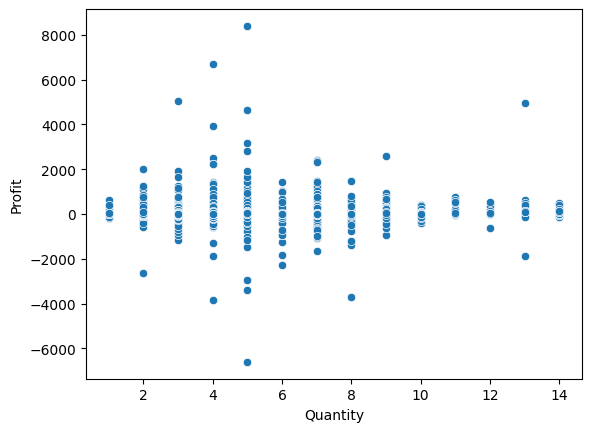

In [23]:
sns.scatterplot(x='Quantity',y='Profit',data=df)

In [ ]:
# spearman is slightly higher for profit vs quantity as compared to pearson which in this case tell us that there is slightly lower relationship b/w profit and quantity which also justifiable using scatter plot. But this doesn't prove that more quantity caused low or higher profit which need further analysis

# Task 5

<Axes: xlabel='Category', ylabel='Region'>

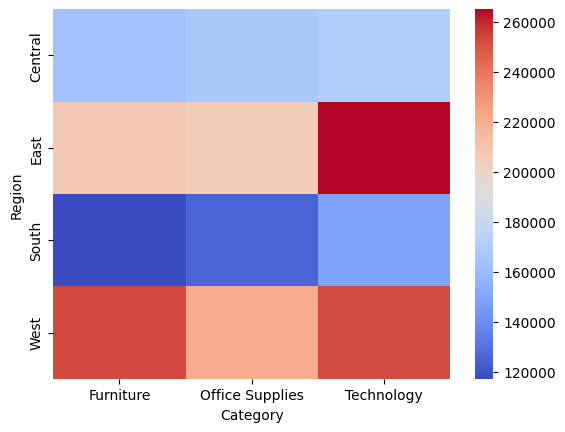

In [33]:
sales_by_region_and_category = df.pivot_table(index='Region',columns='Category',values='Sales',aggfunc='sum')
sns.heatmap(sales_by_region_and_category,cmap ='coolwarm')

In [29]:
# east region has highest technology sales
# remove margins to see which region has highest sales (easily)
# overall west is contributing most to the revenue

array(['South', 'West', 'Central', 'East'], dtype=object)

# Time series analysis

In [36]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

<Axes: xlabel='Order Date', ylabel='Sales'>

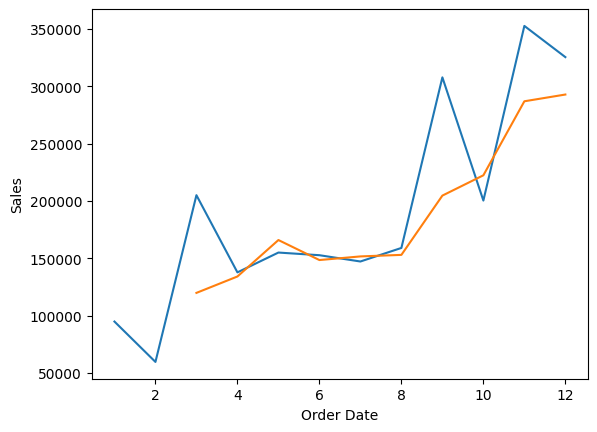

In [39]:
monthly_sales = df.groupby(df['Order Date'].dt.month)['Sales'].sum()
monthly_totals_rolling = monthly_sales.rolling(window=3).mean()
sns.lineplot(monthly_sales)
sns.lineplot(monthly_totals_rolling)

### Due to sliding window of 3 month it tell us the average of every 3 month and overall trend

# Task 7

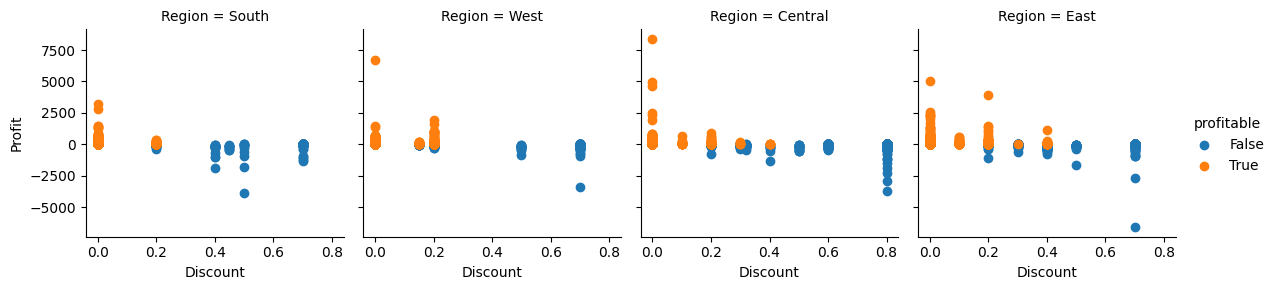

In [49]:
df['profitable'] = df['Profit']>0
graph = sns.FacetGrid(df,col = 'Region',hue='profitable')
graph.map(plt.scatter,'Discount','Profit').add_legend()


In [ ]:
# the central region has given the highest percentage of discount but when discount is higher than 0.8 then profit is dropping higher and also when discount is 0 the profit is higher than all other regions

Text(0.1, 8499.976, 'Highest Profit: 8399.976')

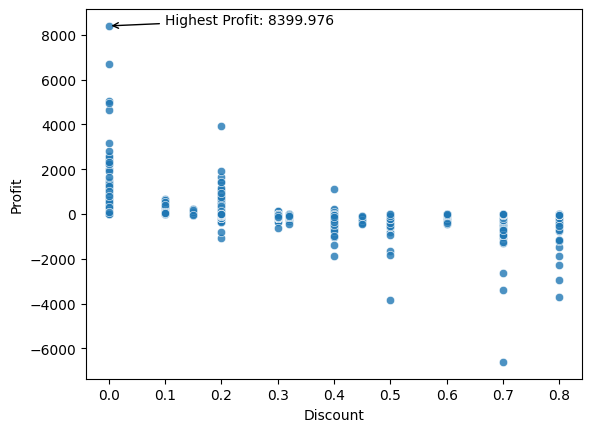

In [74]:
# Task 8
best = df.loc[df['Profit'].idxmax()]
sns.scatterplot(x='Discount',y='Profit',data=df,alpha=0.8)
plt.annotate(
    f"Highest Profit: {best['Profit']}",
    xy=(best['Discount'],best['Profit']),
    xytext=(best['Discount']+0.1,best['Profit']+100),
    arrowprops=dict(arrowstyle='->',color='black')
    )

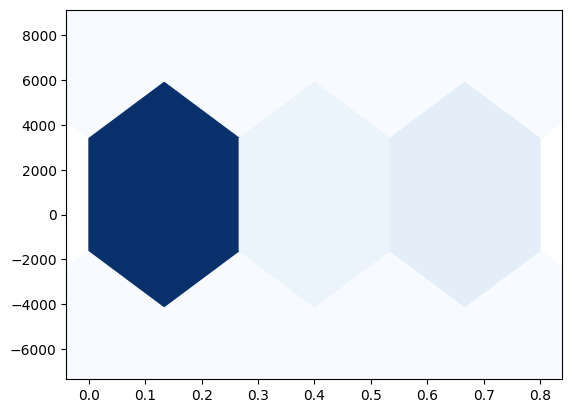

In [59]:
plt.hexbin(df['Discount'],df['Profit'],gridsize=3,cmap='Blues')

In [ ]:
# alpha is more better in this case because it is easy to visualize how discount and profit relate